# Customer Segmentation using K-Means Clustering

End-to-end unsupervised learning pipeline: data cleaning, feature scaling,
optimal-k selection (elbow + silhouette), K-Means fitting, cluster
visualization, and business persona labeling.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import load_data, clean_data, scale_features, FEATURES
from clustering import evaluate_k_range, best_k_by_silhouette, fit_kmeans

sns.set_style('whitegrid')
%matplotlib inline

## 1. Load & Clean Data

In [2]:
raw = load_data('../data/customer_data.csv')
df = clean_data(raw)
print(f"{len(raw)} raw rows -> {len(df)} clean rows")
df.head()

500 raw rows -> 500 clean rows


,CustomerID,Gender,Age,Annual_Income_k,Spending_Score,Annual_Purchases
0,CUST1000,Female,30,99.2,18.5,21
1,CUST1001,Male,26,20.6,98.9,52
2,CUST1002,Male,27,89.8,23.3,11
3,CUST1003,Male,43,91.3,84.6,71
4,CUST1004,Female,45,70.0,76.9,70


## 2. Exploratory Data Analysis

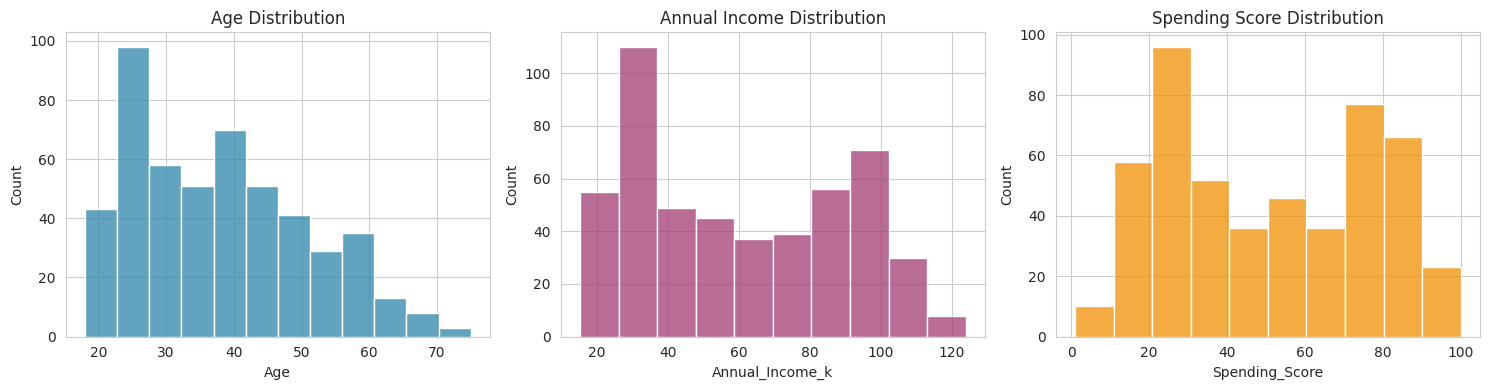

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(df['Age'], ax=axes[0], color='#2E86AB')
sns.histplot(df['Annual_Income_k'], ax=axes[1], color='#A23B72')
sns.histplot(df['Spending_Score'], ax=axes[2], color='#F18F01')
axes[0].set_title('Age Distribution')
axes[1].set_title('Annual Income Distribution')
axes[2].set_title('Spending Score Distribution')
plt.tight_layout()
plt.show()

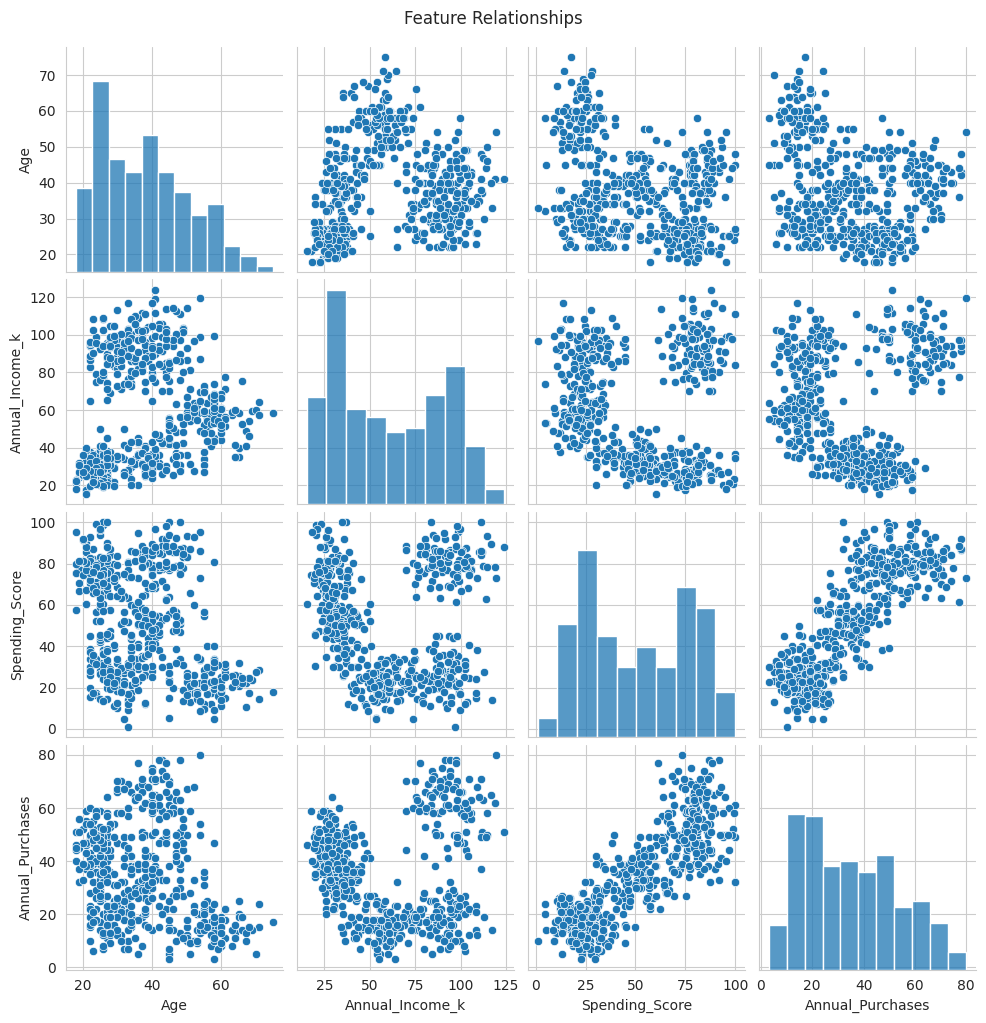

In [4]:
sns.pairplot(df[FEATURES])
plt.suptitle('Feature Relationships', y=1.02)
plt.show()

## 3. Feature Scaling

In [5]:
scaled_df, scaler = scale_features(df)
X = scaled_df.values
scaled_df.describe()

,Age_scaled,Annual_Income_k_scaled,Spending_Score_scaled,Annual_Purchases_scaled
count,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02
mean,-7.105427e-18,-1.669775e-16,-2.629008e-16,1.918465e-16
std,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00
min,-1.573248e+00,-1.561034e+00,-1.898788e+00,-1.707765e+00
25%,-8.654988e-01,-9.570627e-01,-9.489304e-01,-8.429645e-01
50%,-1.184301e-01,-1.287597e-01,-2.946838e-02,-1.403139e-01
75%,7.072775e-01,9.592508e-01,9.792802e-01,7.785368e-01
max,2.909164e+00,2.193940e+00,1.862648e+00,2.454088e+00


## 4. Selecting k: Elbow Method + Silhouette Score

In [6]:
eval_df = evaluate_k_range(X, k_range=range(2, 11))
eval_df

,k,inertia,silhouette_score
0,2,1189.474946,0.380781
1,3,723.560017,0.471007
2,4,423.925334,0.533769
3,5,289.429846,0.536198
4,6,265.795610,0.485031
5,7,243.389141,0.420332
6,8,226.019261,0.348741
7,9,213.791354,0.317193
8,10,205.091063,0.253534


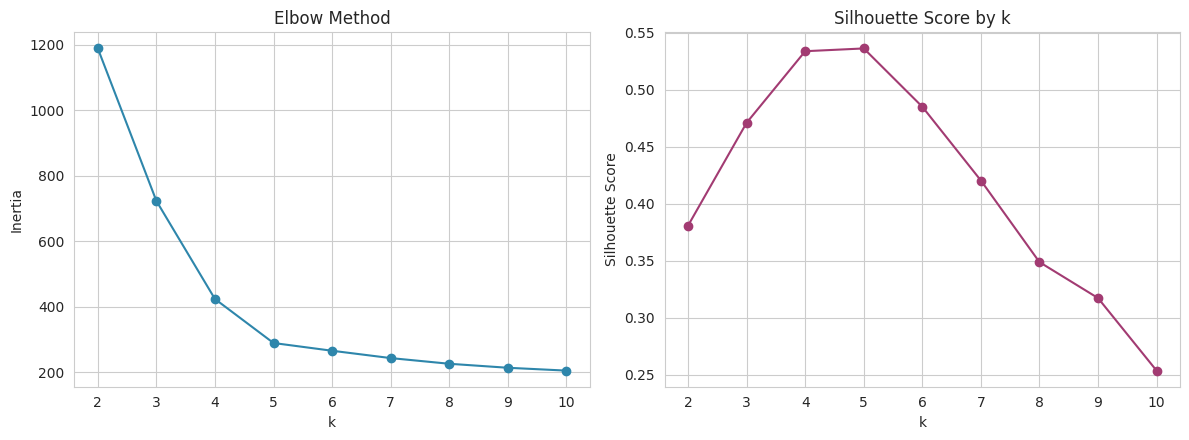

Selected k = 5


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(eval_df['k'], eval_df['inertia'], marker='o', color='#2E86AB')
axes[0].set_title('Elbow Method'); axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')
axes[1].plot(eval_df['k'], eval_df['silhouette_score'], marker='o', color='#A23B72')
axes[1].set_title('Silhouette Score by k'); axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')
plt.tight_layout()
plt.show()

best_k = best_k_by_silhouette(eval_df)
print(f'Selected k = {best_k}')

## 5. Fit Final Model & Visualize Clusters

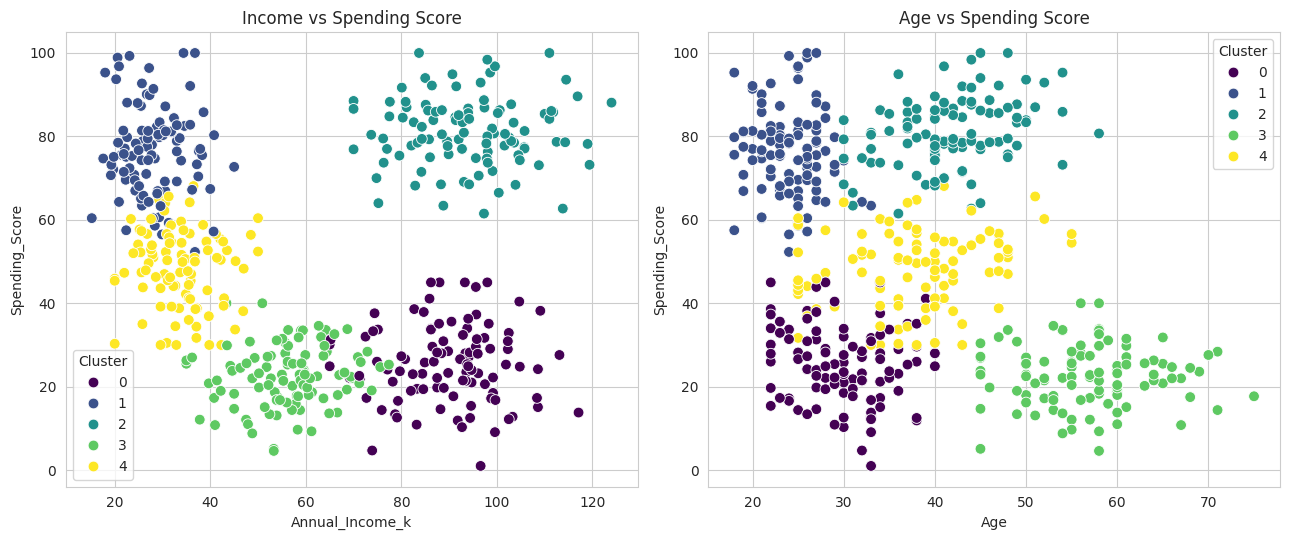

In [8]:
model, labels = fit_kmeans(X, best_k)
df['Cluster'] = labels

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.scatterplot(data=df, x='Annual_Income_k', y='Spending_Score', hue='Cluster', palette='viridis', s=60, ax=axes[0])
sns.scatterplot(data=df, x='Age', y='Spending_Score', hue='Cluster', palette='viridis', s=60, ax=axes[1])
axes[0].set_title('Income vs Spending Score')
axes[1].set_title('Age vs Spending Score')
plt.tight_layout()
plt.show()

## 6. Business Insights

In [9]:
summary = df.groupby('Cluster')[FEATURES].mean().round(1)
summary['count'] = df.groupby('Cluster').size()
summary

,Age,Annual_Income_k,Spending_Score,Annual_Purchases,count
Cluster,,,,,
0,29.8,89.8,25.5,18.5,100
1,24.0,28.1,76.6,45.6,104
2,41.8,94.1,81.1,60.4,100
3,56.9,56.2,22.4,15.0,101
4,38.0,33.9,48.4,33.3,95


Each cluster centroid maps to a distinct customer persona (e.g. young
high-spenders on modest incomes vs. high-income customers who spend
conservatively), which can directly inform targeted marketing, retention
strategy, and customer lifetime value modeling.